In [1]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    # Not running in Jupyter, so skip the magic command
    import matplotlib
    matplotlib.use("Agg")

import os

import numpy as np
import anacal
import fitsio
import matplotlib.pylab as plt

In [2]:
npix = 64
pixel_scale = 0.2  # LSST image pixel scale
# noise variance for r-bands 10 year LSST coadd (magnitude zero point at 30)
noise_std = 0.37
noise_variance = noise_std**2.0
noise_array = None
seed = 2

# Pre-rendered with GalSim by tests/data/make_fixtures.py: a Moffat PSF
# (beta 3.5, fwhm 0.6) and one COSMOS galaxy next to its 90-degree
# rotated copy, sheared by g1 = +0.02 ("g1-1", seed 2), 0.2 arcsec/pixel.
sim_file = os.path.join(os.getcwd(), "isolated_sim.fits")
psf_array = fitsio.read(sim_file, ext="psf")
gal_array = fitsio.read(sim_file, ext="gal_pair")


([], [])

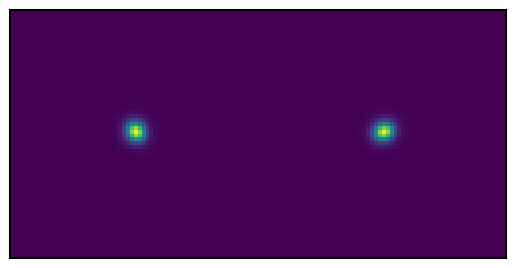

In [3]:
plt.close()
plt.imshow(gal_array, origin="lower")
plt.xticks([])
plt.yticks([])

In [4]:
# Force detections at the centers
indx = np.arange(npix // 2, npix * 2, npix)
indy = np.arange(npix // 2, npix, npix)
ns = len(indx) * len(indy)
inds = np.meshgrid(indy, indx, indexing="ij")
yx = np.vstack([np.ravel(_) for _ in inds])
dtype = np.dtype(
    [
        ("y", np.int32),
        ("x", np.int32),
    ]
)
detection = np.empty(ns, dtype=dtype)
detection["y"] = yx[0]
detection["x"] = yx[1]

In [5]:
# Do measurement
fpfs_config = anacal.fpfs.FpfsConfig(
    sigma_shapelets1=0.52,  # The first measurement scale
    sigma_shapelets2=0.45,  # The second measurement scale
)
catalog = anacal.fpfs.process_image(
    fpfs_config=fpfs_config,
    mag_zero=30.0,
    gal_array=gal_array,
    psf_array=psf_array,
    pixel_scale=pixel_scale,
    noise_variance=max(noise_variance, 0.23),
    noise_array=noise_array,
    detection=detection,
)

# Shear estimate without a selection weight: both galaxies are
# force-measured at their stamp centres (the detection/selection weight
# lives in the AnaCal detector path).
e1 = catalog["fpfs1_e1"]
e1g1 = catalog["fpfs1_de1_dg1"]

mbias = np.sum(e1) / np.sum(e1g1) / 0.02 - 1  # 0.02 is the input shear

In [6]:
print("Multiplicative bias is: ", mbias)

Multiplicative bias is:  -7.480884677901756e-05
